# Instructions
- Some parts of the code are already done for you
- You need to execute all the cells
- You need to add the code where ever you see `"#### Add your code here ####"`
- Marks are mentioned along with the cells

# Face recognition
Task is to recognize a faces

### Dataset
**Aligned Face Dataset from Pinterest**

This dataset contains 10.770 images for 100 people. All images are taken from 'Pinterest' and      aligned using dlib library.

In [1]:
%tensorflow_version 2.x

UsageError: Line magic function `%tensorflow_version` not found.


In [2]:
import tensorflow
tensorflow.__version__

C:\Users\Jatin_Thakkar\AppData\Local\Continuum\anaconda3\envs\tensorflow_env\lib\site-packages\tensorflow\python\framework\dtypes.py:526: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
C:\Users\Jatin_Thakkar\AppData\Local\Continuum\anaconda3\envs\tensorflow_env\lib\site-packages\tensorflow\python\framework\dtypes.py:527: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
C:\Users\Jatin_Thakkar\AppData\Local\Continuum\anaconda3\envs\tensorflow_env\lib\site-packages\tensorflow\python\framework\dtypes.py:528: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
 

'1.13.2'

#### Mount Google drive if you are using google colab
- We recommend using Google Colab as you can face memory issues and longer runtimes while running on local

In [0]:
# Using local machine for technical reasons
#from google.colab import drive
#drive.mount('/content/drive')

#### Change current working directory to project folder (1 mark)

In [0]:
# Not applicable

### Extract the zip file (2 marks)
- Extract Aligned Face Dataset from Pinterest.zip

In [3]:
# importing required modules 
from zipfile import ZipFile 

In [4]:
# specifying the zip file name 
file_name = "Aligned Face Dataset.zip"

In [6]:
# opening the zip file in READ mode 
with ZipFile(file_name, 'r') as zip: 
    # printing all the contents of the zip file 
    #zip.printdir() 
  
    # extracting all the files 
    print('Extracting all the files now...') 
    zip.extractall() 
    print('Done!') 

Extracting all the files now...


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Jatin_Thakkar\\Downloads\\GL_Material\\lab_solutions\\ACV_face_recognition\\PINS\\pins_Natalie Portman \\Natalie Portman 0.jpg'

NOTE: Extracted using windows zip extractor due to the above error 

### Function to load images
- Define a function to load the images from the extracted folder and map each image with person id 


In [7]:
import numpy as np
import os

class IdentityMetadata():
    def __init__(self, base, name, file):
        # print(base, name, file)
        # dataset base directory
        self.base = base
        # identity name
        self.name = name
        # image file name
        self.file = file

    def __repr__(self):
        return self.image_path()

    def image_path(self):
        return os.path.join(self.base, self.name, self.file) 
    
def load_metadata(path):
    metadata = []
    for i in os.listdir(path):
        for f in os.listdir(os.path.join(path, i)):
            # Check file extension. Allow only jpg/jpeg' files.
            ext = os.path.splitext(f)[1]
            if ext == '.jpg' or ext == '.jpeg':
                metadata.append(IdentityMetadata(path, i, f))
    return np.array(metadata)

# metadata = load_metadata('images')
metadata = load_metadata('PINS')

In [9]:
metadata

array([PINS\pins_Aaron Paul\Aaron Paul0_262.jpg,
       PINS\pins_Aaron Paul\Aaron Paul101_247.jpg,
       PINS\pins_Aaron Paul\Aaron Paul101_248.jpg, ...,
       PINS\pins_zendaya\zendaya97.jpg, PINS\pins_zendaya\zendaya98.jpg,
       PINS\pins_zendaya\zendaya99.jpg], dtype=object)

### Define function to load image
- Define a function to load image from the metadata

In [8]:
import cv2
def load_image(path):
    img = cv2.imread(path, 1)
    # OpenCV loads images with color channels
    # in BGR order. So we need to reverse them
    return img[...,::-1]

#### Load a sample image (2 marks)
- Load one image using the function "load_image"

In [11]:
from PIL import Image

In [12]:
sample_image = load_image("PINS/pins_Aaron Paul/Aaron Paul25_285.jpg")

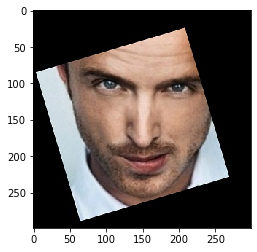

In [14]:
img = Image.fromarray(sample_image, 'RGB')

import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(img)
plt.show()

### VGG Face model
- Here we are giving you the predefined model for VGG face

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ZeroPadding2D, Convolution2D, MaxPooling2D, Dropout, Flatten, Activation

def vgg_face():	
    model = Sequential()
    model.add(ZeroPadding2D((1,1),input_shape=(224,224, 3)))
    model.add(Convolution2D(64, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(128, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(Convolution2D(4096, (7, 7), activation='relu'))
    model.add(Dropout(0.5))
    model.add(Convolution2D(4096, (1, 1), activation='relu'))
    model.add(Dropout(0.5))
    model.add(Convolution2D(2622, (1, 1)))
    model.add(Flatten())
    model.add(Activation('softmax'))
    return model

#### Load the model (2 marks)
- Load the model defined above
- Then load the given weight file named "vgg_face_weights.h5"

In [17]:
from keras.models import load_model
model = vgg_face()
model.load_weights('vgg_face_weights.h5')

Using TensorFlow backend.


Instructions for updating:
Colocations handled automatically by placer.
Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


### Get vgg_face_descriptor

In [18]:
from tensorflow.keras.models import Model
vgg_face_descriptor = Model(inputs=model.layers[0].input, outputs=model.layers[-2].output)

### Generate embeddings for each image in the dataset
- Given below is an example to load the first image in the metadata and get its embedding vector from the pre-trained model. 

In [19]:
# Get embedding vector for first image in the metadata using the pre-trained model

img_path = metadata[0].image_path()
img = load_image(img_path)

# Normalising pixel values from [0-255] to [0-1]: scale RGB values to interval [0,1]
img = (img / 255.).astype(np.float32)

img = cv2.resize(img, dsize = (224,224))
print(img.shape)

# Obtain embedding vector for an image
# Get the embedding vector for the above image using vgg_face_descriptor model and print the shape 

embedding_vector = vgg_face_descriptor.predict(np.expand_dims(img, axis=0))[0]
print(embedding_vector.shape)

(224, 224, 3)
(2622,)


### Generate embeddings for all images (5 marks)
- Write code to iterate through metadata and create embeddings for each image using `vgg_face_descriptor.predict()` and store in a list with name `embeddings`

- If there is any error in reading any image in the dataset, fill the emebdding vector of that image with 2622-zeroes as the final embedding from the model is of length 2622.

In [27]:
import os

directory = os.fsencode("PINS\\")

def list_files(directory):
    r = []
    for root, dirs, files in os.walk(directory):
        for name in files:
            r.append(os.path.join(root, name))
    return r

folders = list_files(directory)

In [28]:
folders[0]

b'PINS\\pins_Aaron Paul\\Aaron Paul0_262.jpg'

In [61]:
embeddings = []
imagesProcessed = 0
for i in range(0,len(folders)):
    filename = folders[i].decode("utf-8")
    
    #img_path = metadata[0].image_path()
    img = load_image(filename)

    # Normalising pixel values from [0-255] to [0-1]: scale RGB values to interval [0,1]
    img = (img / 255.).astype(np.float32)

    img = cv2.resize(img, dsize = (224,224))
    #print(img.shape)

    # Obtain embedding vector for an image
    # Get the embedding vector for the above image using vgg_face_descriptor model and print the shape 

    embedding_vector = vgg_face_descriptor.predict(np.expand_dims(img, axis=0))[0]
    embeddings.append(embedding_vector)
    imagesProcessed += 1
    print("Progress: {}/{} images processed".format(imagesProcessed, len(folders)))
    #print(embedding_vector.shape)

Progress: 1/10770 images processed
Progress: 2/10770 images processed
Progress: 3/10770 images processed
Progress: 4/10770 images processed
Progress: 5/10770 images processed
Progress: 6/10770 images processed
Progress: 7/10770 images processed
Progress: 8/10770 images processed
Progress: 9/10770 images processed
Progress: 10/10770 images processed
Progress: 11/10770 images processed
Progress: 12/10770 images processed
Progress: 13/10770 images processed
Progress: 14/10770 images processed
Progress: 15/10770 images processed
Progress: 16/10770 images processed
Progress: 17/10770 images processed
Progress: 18/10770 images processed
Progress: 19/10770 images processed
Progress: 20/10770 images processed
Progress: 21/10770 images processed
Progress: 22/10770 images processed
Progress: 23/10770 images processed
Progress: 24/10770 images processed
Progress: 25/10770 images processed
Progress: 26/10770 images processed
Progress: 27/10770 images processed
Progress: 28/10770 images processed
P

Progress: 226/10770 images processed
Progress: 227/10770 images processed
Progress: 228/10770 images processed
Progress: 229/10770 images processed
Progress: 230/10770 images processed
Progress: 231/10770 images processed
Progress: 232/10770 images processed
Progress: 233/10770 images processed
Progress: 234/10770 images processed
Progress: 235/10770 images processed
Progress: 236/10770 images processed
Progress: 237/10770 images processed
Progress: 238/10770 images processed
Progress: 239/10770 images processed
Progress: 240/10770 images processed
Progress: 241/10770 images processed
Progress: 242/10770 images processed
Progress: 243/10770 images processed
Progress: 244/10770 images processed
Progress: 245/10770 images processed
Progress: 246/10770 images processed
Progress: 247/10770 images processed
Progress: 248/10770 images processed
Progress: 249/10770 images processed
Progress: 250/10770 images processed
Progress: 251/10770 images processed
Progress: 252/10770 images processed
P

Progress: 448/10770 images processed
Progress: 449/10770 images processed
Progress: 450/10770 images processed
Progress: 451/10770 images processed
Progress: 452/10770 images processed
Progress: 453/10770 images processed
Progress: 454/10770 images processed
Progress: 455/10770 images processed
Progress: 456/10770 images processed
Progress: 457/10770 images processed
Progress: 458/10770 images processed
Progress: 459/10770 images processed
Progress: 460/10770 images processed
Progress: 461/10770 images processed
Progress: 462/10770 images processed
Progress: 463/10770 images processed
Progress: 464/10770 images processed
Progress: 465/10770 images processed
Progress: 466/10770 images processed
Progress: 467/10770 images processed
Progress: 468/10770 images processed
Progress: 469/10770 images processed
Progress: 470/10770 images processed
Progress: 471/10770 images processed
Progress: 472/10770 images processed
Progress: 473/10770 images processed
Progress: 474/10770 images processed
P

Progress: 670/10770 images processed
Progress: 671/10770 images processed
Progress: 672/10770 images processed
Progress: 673/10770 images processed
Progress: 674/10770 images processed
Progress: 675/10770 images processed
Progress: 676/10770 images processed
Progress: 677/10770 images processed
Progress: 678/10770 images processed
Progress: 679/10770 images processed
Progress: 680/10770 images processed
Progress: 681/10770 images processed
Progress: 682/10770 images processed
Progress: 683/10770 images processed
Progress: 684/10770 images processed
Progress: 685/10770 images processed
Progress: 686/10770 images processed
Progress: 687/10770 images processed
Progress: 688/10770 images processed
Progress: 689/10770 images processed
Progress: 690/10770 images processed
Progress: 691/10770 images processed
Progress: 692/10770 images processed
Progress: 693/10770 images processed
Progress: 694/10770 images processed
Progress: 695/10770 images processed
Progress: 696/10770 images processed
P

Progress: 892/10770 images processed
Progress: 893/10770 images processed
Progress: 894/10770 images processed
Progress: 895/10770 images processed
Progress: 896/10770 images processed
Progress: 897/10770 images processed
Progress: 898/10770 images processed
Progress: 899/10770 images processed
Progress: 900/10770 images processed
Progress: 901/10770 images processed
Progress: 902/10770 images processed
Progress: 903/10770 images processed
Progress: 904/10770 images processed
Progress: 905/10770 images processed
Progress: 906/10770 images processed
Progress: 907/10770 images processed
Progress: 908/10770 images processed
Progress: 909/10770 images processed
Progress: 910/10770 images processed
Progress: 911/10770 images processed
Progress: 912/10770 images processed
Progress: 913/10770 images processed
Progress: 914/10770 images processed
Progress: 915/10770 images processed
Progress: 916/10770 images processed
Progress: 917/10770 images processed
Progress: 918/10770 images processed
P

...

Progress: 9751/10770 images processed
Progress: 9752/10770 images processed
Progress: 9753/10770 images processed
Progress: 9754/10770 images processed
Progress: 9755/10770 images processed
Progress: 9756/10770 images processed
Progress: 9757/10770 images processed
Progress: 9758/10770 images processed
Progress: 9759/10770 images processed
Progress: 9760/10770 images processed
Progress: 9761/10770 images processed
Progress: 9762/10770 images processed
Progress: 9763/10770 images processed
Progress: 9764/10770 images processed
Progress: 9765/10770 images processed
Progress: 9766/10770 images processed
Progress: 9767/10770 images processed
Progress: 9768/10770 images processed
Progress: 9769/10770 images processed
Progress: 9770/10770 images processed
Progress: 9771/10770 images processed
Progress: 9772/10770 images processed
Progress: 9773/10770 images processed
Progress: 9774/10770 images processed
Progress: 9775/10770 images processed
Progress: 9776/10770 images processed
Progress: 97

Progress: 9967/10770 images processed
Progress: 9968/10770 images processed
Progress: 9969/10770 images processed
Progress: 9970/10770 images processed
Progress: 9971/10770 images processed
Progress: 9972/10770 images processed
Progress: 9973/10770 images processed
Progress: 9974/10770 images processed
Progress: 9975/10770 images processed
Progress: 9976/10770 images processed
Progress: 9977/10770 images processed
Progress: 9978/10770 images processed
Progress: 9979/10770 images processed
Progress: 9980/10770 images processed
Progress: 9981/10770 images processed
Progress: 9982/10770 images processed
Progress: 9983/10770 images processed
Progress: 9984/10770 images processed
Progress: 9985/10770 images processed
Progress: 9986/10770 images processed
Progress: 9987/10770 images processed
Progress: 9988/10770 images processed
Progress: 9989/10770 images processed
Progress: 9990/10770 images processed
Progress: 9991/10770 images processed
Progress: 9992/10770 images processed
Progress: 99

Progress: 10178/10770 images processed
Progress: 10179/10770 images processed
Progress: 10180/10770 images processed
Progress: 10181/10770 images processed
Progress: 10182/10770 images processed
Progress: 10183/10770 images processed
Progress: 10184/10770 images processed
Progress: 10185/10770 images processed
Progress: 10186/10770 images processed
Progress: 10187/10770 images processed
Progress: 10188/10770 images processed
Progress: 10189/10770 images processed
Progress: 10190/10770 images processed
Progress: 10191/10770 images processed
Progress: 10192/10770 images processed
Progress: 10193/10770 images processed
Progress: 10194/10770 images processed
Progress: 10195/10770 images processed
Progress: 10196/10770 images processed
Progress: 10197/10770 images processed
Progress: 10198/10770 images processed
Progress: 10199/10770 images processed
Progress: 10200/10770 images processed
Progress: 10201/10770 images processed
Progress: 10202/10770 images processed
Progress: 10203/10770 ima

Progress: 10389/10770 images processed
Progress: 10390/10770 images processed
Progress: 10391/10770 images processed
Progress: 10392/10770 images processed
Progress: 10393/10770 images processed
Progress: 10394/10770 images processed
Progress: 10395/10770 images processed
Progress: 10396/10770 images processed
Progress: 10397/10770 images processed
Progress: 10398/10770 images processed
Progress: 10399/10770 images processed
Progress: 10400/10770 images processed
Progress: 10401/10770 images processed
Progress: 10402/10770 images processed
Progress: 10403/10770 images processed
Progress: 10404/10770 images processed
Progress: 10405/10770 images processed
Progress: 10406/10770 images processed
Progress: 10407/10770 images processed
Progress: 10408/10770 images processed
Progress: 10409/10770 images processed
Progress: 10410/10770 images processed
Progress: 10411/10770 images processed
Progress: 10412/10770 images processed
Progress: 10413/10770 images processed
Progress: 10414/10770 ima

Progress: 10600/10770 images processed
Progress: 10601/10770 images processed
Progress: 10602/10770 images processed
Progress: 10603/10770 images processed
Progress: 10604/10770 images processed
Progress: 10605/10770 images processed
Progress: 10606/10770 images processed
Progress: 10607/10770 images processed
Progress: 10608/10770 images processed
Progress: 10609/10770 images processed
Progress: 10610/10770 images processed
Progress: 10611/10770 images processed
Progress: 10612/10770 images processed
Progress: 10613/10770 images processed
Progress: 10614/10770 images processed
Progress: 10615/10770 images processed
Progress: 10616/10770 images processed
Progress: 10617/10770 images processed
Progress: 10618/10770 images processed
Progress: 10619/10770 images processed
Progress: 10620/10770 images processed
Progress: 10621/10770 images processed
Progress: 10622/10770 images processed
Progress: 10623/10770 images processed
Progress: 10624/10770 images processed
Progress: 10625/10770 ima

In [62]:
import re
delimiters = "\\"

# Generating labels for the dataset
embeddings_labels = []
imagesProcessed = 0
for i in range(0,len(folders)):
    filename = folders[i].decode("utf-8")
    regexPattern = '|'.join(map(re.escape, delimiters))
    output = re.split(regexPattern,filename)
    output_append = output[1]
    #print(output[1])
    embeddings_labels.append(output_append)
    imagesProcessed += 1
    print("Progress: {}/{} images processed".format(imagesProcessed, len(folders)))

Progress: 1/10770 images processed
Progress: 2/10770 images processed
Progress: 3/10770 images processed
Progress: 4/10770 images processed
Progress: 5/10770 images processed
Progress: 6/10770 images processed
Progress: 7/10770 images processed
Progress: 8/10770 images processed
Progress: 9/10770 images processed
Progress: 10/10770 images processed
Progress: 11/10770 images processed
Progress: 12/10770 images processed
Progress: 13/10770 images processed
Progress: 14/10770 images processed
Progress: 15/10770 images processed
Progress: 16/10770 images processed
Progress: 17/10770 images processed
Progress: 18/10770 images processed
Progress: 19/10770 images processed
Progress: 20/10770 images processed
Progress: 21/10770 images processed
Progress: 22/10770 images processed
Progress: 23/10770 images processed
Progress: 24/10770 images processed
Progress: 25/10770 images processed
Progress: 26/10770 images processed
Progress: 27/10770 images processed
Progress: 28/10770 images processed
P

Progress: 726/10770 images processed
Progress: 727/10770 images processed
Progress: 728/10770 images processed
Progress: 729/10770 images processed
Progress: 730/10770 images processed
Progress: 731/10770 images processed
Progress: 732/10770 images processed
Progress: 733/10770 images processed
Progress: 734/10770 images processed
Progress: 735/10770 images processed
Progress: 736/10770 images processed
Progress: 737/10770 images processed
Progress: 738/10770 images processed
Progress: 739/10770 images processed
Progress: 740/10770 images processed
Progress: 741/10770 images processed
Progress: 742/10770 images processed
Progress: 743/10770 images processed
Progress: 744/10770 images processed
Progress: 745/10770 images processed
Progress: 746/10770 images processed
Progress: 747/10770 images processed
Progress: 748/10770 images processed
Progress: 749/10770 images processed
Progress: 750/10770 images processed
Progress: 751/10770 images processed
Progress: 752/10770 images processed
P

Progress: 1054/10770 images processed
Progress: 1055/10770 images processed
Progress: 1056/10770 images processed
Progress: 1057/10770 images processed
Progress: 1058/10770 images processed
Progress: 1059/10770 images processed
Progress: 1060/10770 images processed
Progress: 1061/10770 images processed
Progress: 1062/10770 images processed
Progress: 1063/10770 images processed
Progress: 1064/10770 images processed
Progress: 1065/10770 images processed
Progress: 1066/10770 images processed
Progress: 1067/10770 images processed
Progress: 1068/10770 images processed
Progress: 1069/10770 images processed
Progress: 1070/10770 images processed
Progress: 1071/10770 images processed
Progress: 1072/10770 images processed
Progress: 1073/10770 images processed
Progress: 1074/10770 images processed
Progress: 1075/10770 images processed
Progress: 1076/10770 images processed
Progress: 1077/10770 images processed
Progress: 1078/10770 images processed
Progress: 1079/10770 images processed
Progress: 10

Progress: 1917/10770 images processed
Progress: 1918/10770 images processed
Progress: 1919/10770 images processed
Progress: 1920/10770 images processed
Progress: 1921/10770 images processed
Progress: 1922/10770 images processed
Progress: 1923/10770 images processed
Progress: 1924/10770 images processed
Progress: 1925/10770 images processed
Progress: 1926/10770 images processed
Progress: 1927/10770 images processed
Progress: 1928/10770 images processed
Progress: 1929/10770 images processed
Progress: 1930/10770 images processed
Progress: 1931/10770 images processed
Progress: 1932/10770 images processed
Progress: 1933/10770 images processed
Progress: 1934/10770 images processed
Progress: 1935/10770 images processed
Progress: 1936/10770 images processed
Progress: 1937/10770 images processed
Progress: 1938/10770 images processed
Progress: 1939/10770 images processed
Progress: 1940/10770 images processed
Progress: 1941/10770 images processed
Progress: 1942/10770 images processed
Progress: 19

Progress: 2257/10770 images processed
Progress: 2258/10770 images processed
Progress: 2259/10770 images processed
Progress: 2260/10770 images processed
Progress: 2261/10770 images processed
Progress: 2262/10770 images processed
Progress: 2263/10770 images processed
Progress: 2264/10770 images processed
Progress: 2265/10770 images processed
Progress: 2266/10770 images processed
Progress: 2267/10770 images processed
Progress: 2268/10770 images processed
Progress: 2269/10770 images processed
Progress: 2270/10770 images processed
Progress: 2271/10770 images processed
Progress: 2272/10770 images processed
Progress: 2273/10770 images processed
Progress: 2274/10770 images processed
Progress: 2275/10770 images processed
Progress: 2276/10770 images processed
Progress: 2277/10770 images processed
Progress: 2278/10770 images processed
Progress: 2279/10770 images processed
Progress: 2280/10770 images processed
Progress: 2281/10770 images processed
Progress: 2282/10770 images processed
Progress: 22

...

Progress: 8455/10770 images processed
Progress: 8456/10770 images processed
Progress: 8457/10770 images processed
Progress: 8458/10770 images processed
Progress: 8459/10770 images processed
Progress: 8460/10770 images processed
Progress: 8461/10770 images processed
Progress: 8462/10770 images processed
Progress: 8463/10770 images processed
Progress: 8464/10770 images processed
Progress: 8465/10770 images processed
Progress: 8466/10770 images processed
Progress: 8467/10770 images processed
Progress: 8468/10770 images processed
Progress: 8469/10770 images processed
Progress: 8470/10770 images processed
Progress: 8471/10770 images processed
Progress: 8472/10770 images processed
Progress: 8473/10770 images processed
Progress: 8474/10770 images processed
Progress: 8475/10770 images processed
Progress: 8476/10770 images processed
Progress: 8477/10770 images processed
Progress: 8478/10770 images processed
Progress: 8479/10770 images processed
Progress: 8480/10770 images processed
Progress: 84

Progress: 9121/10770 images processed
Progress: 9122/10770 images processed
Progress: 9123/10770 images processed
Progress: 9124/10770 images processed
Progress: 9125/10770 images processed
Progress: 9126/10770 images processed
Progress: 9127/10770 images processed
Progress: 9128/10770 images processed
Progress: 9129/10770 images processed
Progress: 9130/10770 images processed
Progress: 9131/10770 images processed
Progress: 9132/10770 images processed
Progress: 9133/10770 images processed
Progress: 9134/10770 images processed
Progress: 9135/10770 images processed
Progress: 9136/10770 images processed
Progress: 9137/10770 images processed
Progress: 9138/10770 images processed
Progress: 9139/10770 images processed
Progress: 9140/10770 images processed
Progress: 9141/10770 images processed
Progress: 9142/10770 images processed
Progress: 9143/10770 images processed
Progress: 9144/10770 images processed
Progress: 9145/10770 images processed
Progress: 9146/10770 images processed
Progress: 91

Progress: 9459/10770 images processed
Progress: 9460/10770 images processed
Progress: 9461/10770 images processed
Progress: 9462/10770 images processed
Progress: 9463/10770 images processed
Progress: 9464/10770 images processed
Progress: 9465/10770 images processed
Progress: 9466/10770 images processed
Progress: 9467/10770 images processed
Progress: 9468/10770 images processed
Progress: 9469/10770 images processed
Progress: 9470/10770 images processed
Progress: 9471/10770 images processed
Progress: 9472/10770 images processed
Progress: 9473/10770 images processed
Progress: 9474/10770 images processed
Progress: 9475/10770 images processed
Progress: 9476/10770 images processed
Progress: 9477/10770 images processed
Progress: 9478/10770 images processed
Progress: 9479/10770 images processed
Progress: 9480/10770 images processed
Progress: 9481/10770 images processed
Progress: 9482/10770 images processed
Progress: 9483/10770 images processed
Progress: 9484/10770 images processed
Progress: 94

Progress: 10031/10770 images processed
Progress: 10032/10770 images processed
Progress: 10033/10770 images processed
Progress: 10034/10770 images processed
Progress: 10035/10770 images processed
Progress: 10036/10770 images processed
Progress: 10037/10770 images processed
Progress: 10038/10770 images processed
Progress: 10039/10770 images processed
Progress: 10040/10770 images processed
Progress: 10041/10770 images processed
Progress: 10042/10770 images processed
Progress: 10043/10770 images processed
Progress: 10044/10770 images processed
Progress: 10045/10770 images processed
Progress: 10046/10770 images processed
Progress: 10047/10770 images processed
Progress: 10048/10770 images processed
Progress: 10049/10770 images processed
Progress: 10050/10770 images processed
Progress: 10051/10770 images processed
Progress: 10052/10770 images processed
Progress: 10053/10770 images processed
Progress: 10054/10770 images processed
Progress: 10055/10770 images processed
Progress: 10056/10770 ima

Progress: 10442/10770 images processed
Progress: 10443/10770 images processed
Progress: 10444/10770 images processed
Progress: 10445/10770 images processed
Progress: 10446/10770 images processed
Progress: 10447/10770 images processed
Progress: 10448/10770 images processed
Progress: 10449/10770 images processed
Progress: 10450/10770 images processed
Progress: 10451/10770 images processed
Progress: 10452/10770 images processed
Progress: 10453/10770 images processed
Progress: 10454/10770 images processed
Progress: 10455/10770 images processed
Progress: 10456/10770 images processed
Progress: 10457/10770 images processed
Progress: 10458/10770 images processed
Progress: 10459/10770 images processed
Progress: 10460/10770 images processed
Progress: 10461/10770 images processed
Progress: 10462/10770 images processed
Progress: 10463/10770 images processed
Progress: 10464/10770 images processed
Progress: 10465/10770 images processed
Progress: 10466/10770 images processed
Progress: 10467/10770 ima

### Function to calculate distance between given 2 pairs of images.

- Consider distance metric as "Squared L2 distance"
- Squared l2 distance between 2 points (x1, y1) and (x2, y2) = (x1-x2)^2 + (y1-y2)^2

In [63]:
def distance(emb1, emb2):
    return np.sum(np.square(emb1 - emb2))

#### Plot images and get distance between the pairs given below
- 2, 3 and 2, 180
- 30, 31 and 30, 100
- 70, 72 and 70, 115

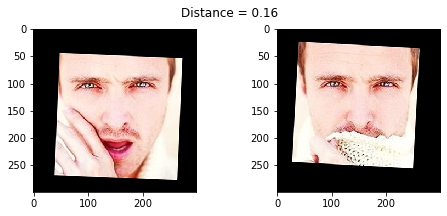

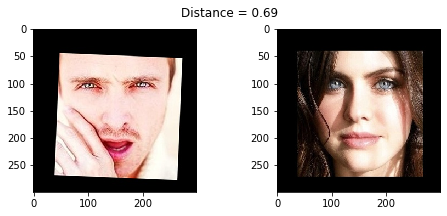

In [64]:
import matplotlib.pyplot as plt

def show_pair(idx1, idx2):
    plt.figure(figsize=(8,3))
    plt.suptitle(f'Distance = {distance(embeddings[idx1], embeddings[idx2]):.2f}')
    plt.subplot(121)
    plt.imshow(load_image(metadata[idx1].image_path()))
    plt.subplot(122)
    plt.imshow(load_image(metadata[idx2].image_path()));    

show_pair(2, 3)
show_pair(2, 180)

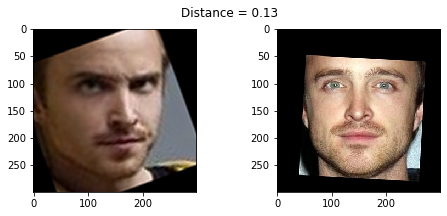

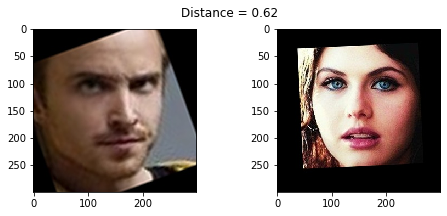

In [65]:
show_pair(30, 31)
show_pair(30, 100)

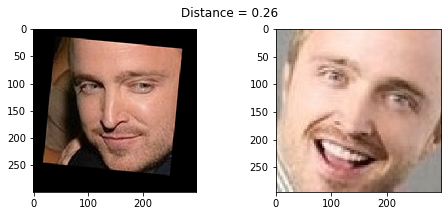

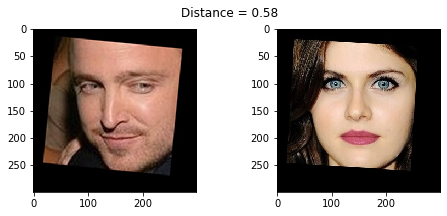

In [66]:
show_pair(70, 72)
show_pair(70, 115)

### Create train and test sets (5 marks)
- Create X_train, X_test and y_train, y_test
- Use train_idx to seperate out training features and labels
- Use test_idx to seperate out testing features and labels

In [68]:
train_idx = np.arange(metadata.shape[0]) % 9 != 0
test_idx = np.arange(metadata.shape[0]) % 9 == 0
print(train_idx)
print(test_idx)

from itertools import compress

embeddings_x = embeddings.copy()
X_train = list(compress(embeddings_x, train_idx))
X_test = list(compress(embeddings_x, test_idx))
#embeddings_labels_relevant = embeddings_labels[0][1]
y_train = list(compress(embeddings_labels, train_idx))
y_test = list(compress(embeddings_labels, test_idx))

print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

[False  True  True ...  True  True  True]
[ True False False ... False False False]
9573
1197
9573
1197


### Encode the Labels (3 marks)
- Encode the targets
- Use LabelEncoder

In [70]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
print(len(y_train))
print(len(y_test))

9573
1197


### Standardize the feature values (3 marks)
- Scale the features using StandardScaler

In [71]:
# Standarize features
from sklearn.preprocessing import StandardScaler

X_train_std = StandardScaler().fit_transform(X_train)
X_test_std = StandardScaler().fit_transform(X_test)

### Reduce dimensions using PCA (3 marks)
- Reduce feature dimensions using Principal Component Analysis

In [73]:
from sklearn.decomposition import PCA

myset = set(embeddings_labels)
n_classes = len(myset)
print(n_classes)

100


In [77]:
# Compute a PCA (eigenfaces) on the face dataset
n_components = 200

print("Extracting the top {} eigenfaces from {} faces".format(n_components, X_train_std.shape[0]))
pca = PCA(n_components=n_components, whiten=True).fit(X_train_std)

# Transform data into principal components representation
X_train_pca = pca.transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

Extracting the top 200 eigenfaces from 9573 faces


### Build a Classifier (3 marks)
- Use SVM Classifier to predict the person in the given image
- Fit the classifier and print the score

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Train an SVM classification model

print("Fitting the classifier to the training set")

param_grid = {
    'C': [1e3],
    'gamma':[0.001]
}

# Instantiate model
svm = SVC(kernel='rbf', class_weight='balanced', random_state=42)

# GridSearch
clf = GridSearchCV(svm, param_grid)
clf.fit(X_train_pca, y_train)
print(clf.best_estimator_)

Fitting the classifier to the training set


C:\Users\Jatin_Thakkar\AppData\Local\Continuum\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\model_selection\_split.py:1978: FutureWarning: The default value of cv will change from 3 to 5 in version 0.22. Specify it explicitly to silence this warning.
  warnings.warn(CV_WARNING, FutureWarning)


In [ ]:
# Quantitative evaluation of the model quality on the test set
print("Predicting the people names on the testing test")
y_pred = clf.predict(X_test_pca)

In [ ]:
# Classification report and confusion matrix
print(classification_report(y_test, y_pred, target_names=myset))

### Test results (1 mark)
- Take 10th image from test set and plot the image
- Report to which person(folder name in dataset) the image belongs to

In [0]:
import warnings
# Suppress LabelEncoder warning
warnings.filterwarnings('ignore')

example_idx = 10

example_image = load_image(metadata[test_idx][example_idx].image_path())
example_prediction = #### Add your code here ####
example_identity = encoder.inverse_transform(example_prediction)[0]

plt.imshow(example_image)
plt.title(f'Identified as {example_identity}');